# Baseline Metrics — Simulation Validation

Quantify the simulation's output **distributions** and validate them against NYP operational benchmarks. Each section shows a distribution (across replications or across patients) rather than a single point estimate, to reveal how stable the model is and where uncertainty is highest.

| Section | What it shows | Comparison target |
|---|---|---|
| **Wait Time Distributions** | Days from patient creation to each care step | NYP scheduling data |
| **Revenue Distributions** | Realized & foregone revenue per procedure | NYP Finance / CPT contract rates |
| **Screening & LTFU Rates** | Cervical screening, abnormal, LTFU, colposcopy completion | HEDIS / NYP EHR rates |
| **Cervical Result Distribution** | Result-category mix vs. expected probabilities | ASCCP / NCI prevalence tables |
| **Lung-RADS Distribution** | RADS category mix vs. expected | ACR national data / NYP LDCT program |
| **Summary Validation Table** | All key metrics: mean ± std vs. hospital reference | NYP benchmark targets |

> All rate parameters are **placeholders**. Replace `config.py` values with NYP EHR-derived rates before using for operational planning.  
> Revenue figures use placeholder CPT rates — replace `cfg.PROCEDURE_REVENUE` with NYP contract rates.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import defaultdict

import config as cfg
from runner import SimulationRunner
from metrics import compute_rates, compute_revenue

In [2]:
# =============================================================================
# NYP HOSPITAL REFERENCE DATA
# Replace each value below with actual data from NYP EHR / Finance / LDCT program.
# All values are MADE-UP PLACEHOLDERS for calibration illustration only.
# =============================================================================

NYP_REFERENCE = {

    # ── Wait times: median days at NYP from referral / creation to care step ──
    # Source: NYP scheduling data (TBD)
    "wait_days_median": {
        "screening_seen": 4,     # days to screening appointment
        "colposcopy":     25,    # referral-to-colposcopy
        "leep":           18,    # colposcopy-to-LEEP
        "lung_biopsy":    16,    # RADS 4 result to CT-guided biopsy
    },

    # ── Annual procedure revenue ($) ─────────────────────────────────────────
    # Source: NYP Finance / CPT contract rates (TBD)
    "realized_revenue_annual": {
        "cervical_screening": 820_000,
        "colposcopy":         410_000,
        "leep":               220_000,
        "cone_biopsy":         35_000,
        "ldct":               310_000,
        "lung_biopsy":         72_000,
        "lung_treatment":     160_000,
    },
    "realized_total_annual":   2_027_000,
    "foregone_total_annual":     280_000,
    "capture_rate_pct":           87.9,

    # ── Screening & LTFU rates (%) ───────────────────────────────────────────
    # Source: NYP EHR / HEDIS report (TBD)
    "rates": {
        "screening_rate_cervical_pct":  71.8,
        "unscreened_pct":               28.2,
        "abnormal_rate_cervical_pct":    8.1,
        "colposcopy_completion_pct":    74.5,
        "treatment_completion_pct":     33.2,
        "ltfu_rate_pct":                11.4,
    },

    # ── Lung-RADS biopsy-trigger rate (%) ────────────────────────────────────
    # Source: NYP LDCT program data (TBD)
    "rads4_rate_pct": 7.3,

    # ── Volume counts (annual) ────────────────────────────────────────────────
    # Source: NYP EHR (TBD)
    "n_patients_annual":           68_400,
    "n_eligible_cervical_annual":  31_200,
    "n_eligible_lung_annual":       1_850,
    "n_ldct_completed_annual":      1_320,
    "n_malignancy_confirmed":           9,
}

print("NYP reference values loaded  (*** PLACEHOLDER — replace with real data ***)")

NYP reference values loaded  (*** PLACEHOLDER — replace with real data ***)


---

## Setup — Multi-Replication Run

We run `N_REPS` independent replications of a 1-year (365-day) simulation, each with a different random seed, to build up two types of data:

- **Per-patient distributions** — pooled `wait_times` lists across all reps (large sample → stable histograms)
- **Per-replication summaries** — scalar metrics (rates, revenue) from each rep, shown as box plots

Increase `N_REPS` for tighter confidence intervals; decrease it to run faster. 20 reps typically takes ~30 seconds.

In [3]:
N_REPS = 20
N_DAYS = 365

all_metrics  = []                  # one dict per replication
pooled_waits = defaultdict(list)   # resource → patient wait times (all reps pooled)

for rep in range(N_REPS):
    sim = SimulationRunner(n_days=N_DAYS, seed=cfg.RANDOM_SEED + rep)
    m   = sim.run()
    all_metrics.append(m)
    for resource, times in m['wait_times'].items():
        pooled_waits[resource].extend(times)

print(f"Completed {N_REPS} replications  ·  {N_DAYS}-day horizon each")
print(f"Total pooled wait-time observations: {sum(len(v) for v in pooled_waits.values()):,}")
print(f"Resources with wait-time data: {sorted(pooled_waits.keys())}")

Completed 20 replications  ·  365-day horizon each
Total pooled wait-time observations: 1,109,072
Resources with wait-time data: ['colposcopy', 'leep', 'screening_seen']


---

## Wait Time Distributions

Each bar below is a **patient-level observation** pooled across all replications. Long right tails signal capacity bottlenecks — patients waiting well beyond the median. The vertical lines show the median, mean, and 90th percentile.

> **Unit:** Days from patient creation to the care event (includes scheduling lead time and any queue delay).  
> **PENDING:** Replace `cfg.FOLLOWUP_DELAY_DAYS` with empirical distributions from NYP scheduling data so these match real wait times.

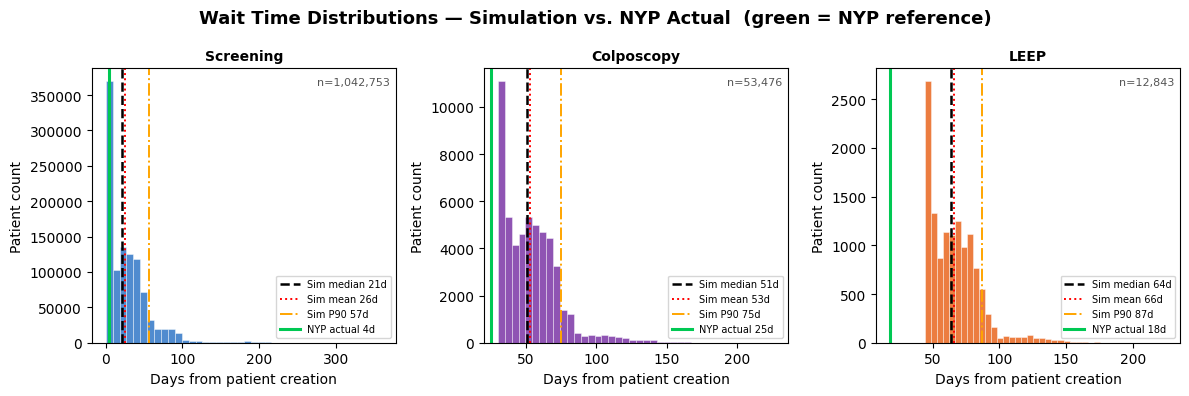

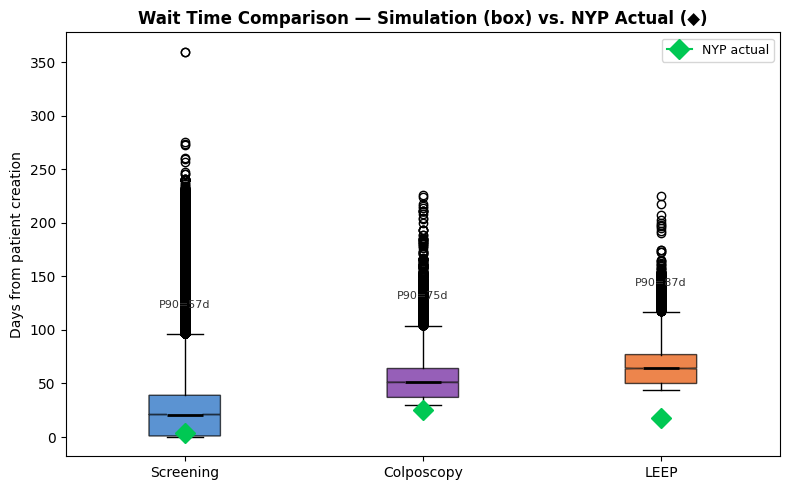


Resource                   N  Sim Mean  Sim Med  Sim P90  NYP Actual  Gap (sim−nyp)
----------------------------------------------------------------------------------
Screening            1,042,753      25.7     21.0     57.0          4d         +17.0d
Colposcopy            53,476      53.1     51.0     75.0         25d         +26.0d
LEEP                  12,843      66.1     64.0     87.0         18d         +46.0d


In [4]:
resources_ordered = ['screening_seen', 'colposcopy', 'leep', 'cone_biopsy', 'lung_biopsy']
resource_labels   = {
    'screening_seen': 'Screening',
    'colposcopy':     'Colposcopy',
    'leep':           'LEEP',
    'cone_biopsy':    'Cone Biopsy',
    'lung_biopsy':    'Lung Biopsy',
}
res_colors = ['#1565C0', '#6A1B9A', '#E65100', '#2E7D32', '#C62828']

present = [
    (r, resource_labels[r], c)
    for r, c in zip(resources_ordered, res_colors)
    if r in pooled_waits and len(pooled_waits[r]) > 0
]

if not present:
    print("No wait-time data. Check that patients are completing appointments.")
else:
    n_res = len(present)

    # ── Row 1: Per-resource histograms ────────────────────────────────────────
    fig, axes = plt.subplots(1, n_res, figsize=(4 * n_res, 4), sharey=False)
    if n_res == 1:
        axes = [axes]

    for ax, (res, lbl, col) in zip(axes, present):
        data = pooled_waits[res]
        ax.hist(data, bins=40, color=col, alpha=0.75, edgecolor='white', linewidth=0.4)
        med = np.median(data)
        mu  = np.mean(data)
        p90 = np.percentile(data, 90)
        ax.axvline(med, color='black',  linewidth=1.8, linestyle='--', label=f'Sim median {med:.0f}d')
        ax.axvline(mu,  color='red',    linewidth=1.4, linestyle=':',  label=f'Sim mean {mu:.0f}d')
        ax.axvline(p90, color='orange', linewidth=1.4, linestyle='-.', label=f'Sim P90 {p90:.0f}d')
        # NYP reference line
        nyp_med = NYP_REFERENCE['wait_days_median'].get(res)
        if nyp_med is not None:
            ax.axvline(nyp_med, color='#00C853', linewidth=2.2, linestyle='-',
                       label=f'NYP actual {nyp_med}d')
        ax.set_title(lbl, fontweight='bold', fontsize=10)
        ax.set_xlabel('Days from patient creation')
        ax.set_ylabel('Patient count')
        ax.legend(fontsize=7)
        ax.text(0.98, 0.97, f'n={len(data):,}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='#555')

    plt.suptitle('Wait Time Distributions — Simulation vs. NYP Actual  (green = NYP reference)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Row 2: Side-by-side box plot with NYP reference markers ───────────────
    fig2, ax2 = plt.subplots(figsize=(max(8, n_res * 2), 5))
    box_data = [pooled_waits[r] for r, _, _ in present]
    box_lbls = [lbl for _, lbl, _ in present]
    bp = ax2.boxplot(box_data, patch_artist=True, notch=True,
                     medianprops=dict(color='black', linewidth=2))
    for patch, (_, _, col) in zip(bp['boxes'], present):
        patch.set_facecolor(col)
        patch.set_alpha(0.70)
    # NYP reference diamonds per resource
    for i, (res, lbl, _) in enumerate(present, 1):
        nyp_med = NYP_REFERENCE['wait_days_median'].get(res)
        if nyp_med is not None:
            ax2.plot(i, nyp_med, marker='D', color='#00C853', markersize=10,
                     zorder=5, label='NYP actual' if i == 1 else '_nolegend_')
    ax2.set_xticklabels(box_lbls, fontsize=10)
    ax2.set_ylabel('Days from patient creation')
    ax2.set_title('Wait Time Comparison — Simulation (box) vs. NYP Actual (◆)',
                  fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    for i, (res, _, _) in enumerate(present, 1):
        d = pooled_waits[res]
        ax2.text(i, np.percentile(d, 99) * 1.04,
                 f'P90={np.percentile(d, 90):.0f}d',
                 ha='center', fontsize=8, color='#333')
    plt.tight_layout()
    plt.show()

    # Summary stats table
    print(f"\n{'Resource':<20} {'N':>7} {'Sim Mean':>9} {'Sim Med':>8} {'Sim P90':>8} {'NYP Actual':>11}  {'Gap (sim−nyp)':>13}")
    print("-" * 82)
    for res, lbl, _ in present:
        d = pooled_waits[res]
        nyp_med = NYP_REFERENCE['wait_days_median'].get(res)
        nyp_str = f"{nyp_med}d" if nyp_med is not None else "TBD"
        gap_str = f"{np.median(d) - nyp_med:+.1f}d" if nyp_med is not None else "—"
        print(f"{lbl:<20} {len(d):>7,} {np.mean(d):>9.1f} {np.median(d):>8.1f} "
              f"{np.percentile(d,90):>8.1f} {nyp_str:>11}  {gap_str:>13}")

---

## Revenue Distributions

Box plots show the spread of realized and foregone revenue **across replications** — each dot is one 1-year run. Wide boxes indicate high run-to-run variability (sensitive to rare events or random patient mix). Uncomment the red reference lines once NYP Finance data is available.

> Revenue rates are placeholder CPT values — replace `cfg.PROCEDURE_REVENUE` with NYP contract rates.

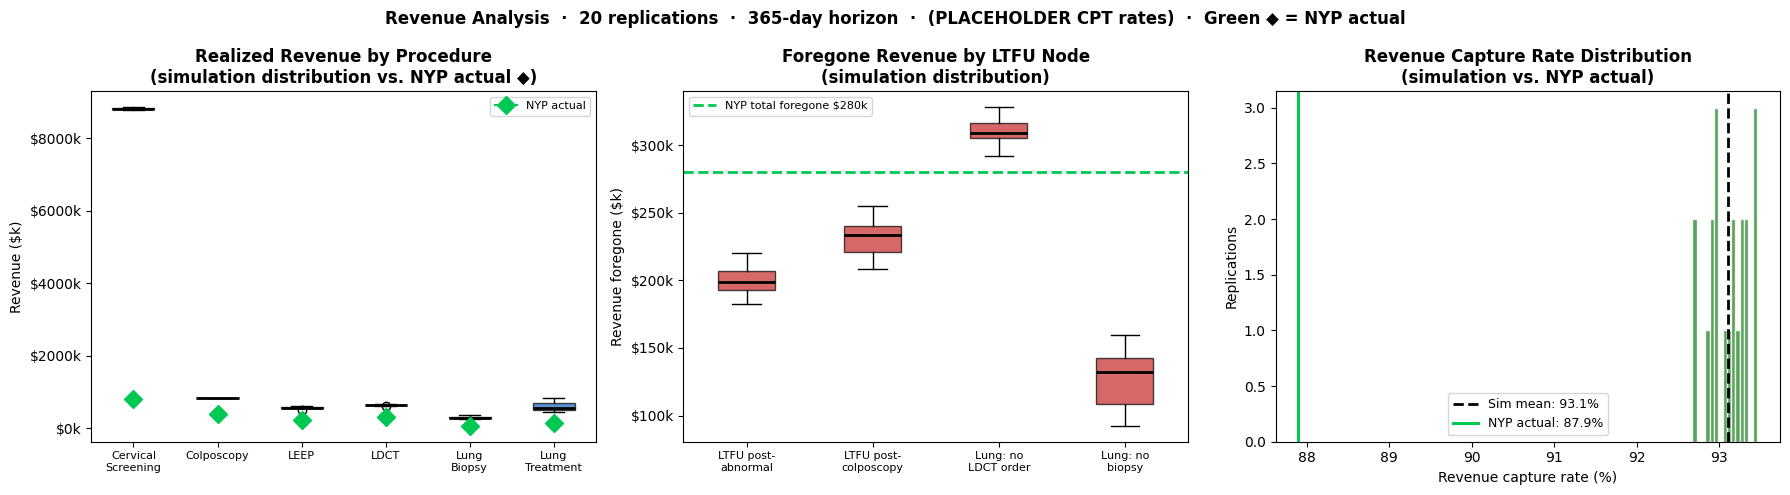


Metric                             Sim Mean    Sim Std   NYP Actual   Gap (sim−nyp)
-------------------------------------------------------------------------------------
Realized total ($)              $11,759,218   ±155,256   $2,027,000      $9,732,218
Foregone total ($)                 $869,792    ±27,959     $280,000        $589,792
Capture rate (%)                      93.1%      ±0.2%        87.9%            5.2%


In [5]:
proc_labels = {
    'cervical_screening': 'Cervical\nScreening',
    'colposcopy':         'Colposcopy',
    'leep':               'LEEP',
    'cone_biopsy':        'Cone\nBiopsy',
    'ldct':               'LDCT',
    'lung_biopsy':        'Lung\nBiopsy',
    'lung_treatment':     'Lung\nTreatment',
}
node_labels = {
    'unscreened_cervical':          'Unscreened\n(cervical)',
    'ltfu_post_abnormal_cervical':  'LTFU post-\nabnormal',
    'ltfu_post_colposcopy':         'LTFU post-\ncolposcopy',
    'lung_no_ldct':                 'Lung: no\nLDCT order',
    'lung_no_biopsy':               'Lung: no\nbiopsy',
}

# Collect per-replication revenue
realized_by_proc = defaultdict(list)
foregone_by_node = defaultdict(list)
realized_totals  = []
foregone_totals  = []
capture_rates    = []

for m in all_metrics:
    rev = compute_revenue(m)
    realized_totals.append(rev['realized_total'])
    foregone_totals.append(rev['foregone_total'])
    total_addr = rev['realized_total'] + rev['foregone_total']
    capture_rates.append(100 * rev['realized_total'] / max(total_addr, 1))
    for proc, val in rev['realized_by_procedure'].items():
        realized_by_proc[proc].append(val)
    for node, val in rev['foregone_by_node'].items():
        foregone_by_node[node].append(val)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: Realized revenue by procedure ────────────────────────────────────
ax = axes[0]
r_keys = [k for k in proc_labels if realized_by_proc[k] and any(v > 0 for v in realized_by_proc[k])]
if r_keys:
    bp1 = ax.boxplot(
        [np.array(realized_by_proc[k]) / 1000 for k in r_keys],
        patch_artist=True, medianprops=dict(color='black', linewidth=2)
    )
    for patch in bp1['boxes']:
        patch.set_facecolor('#1565C0'); patch.set_alpha(0.70)
    ax.set_xticklabels([proc_labels[k] for k in r_keys], fontsize=8)
    ax.set_ylabel('Revenue ($k)')
    ax.set_title('Realized Revenue by Procedure\n(simulation distribution vs. NYP actual ◆)',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
    # NYP actual diamonds per procedure
    nyp_proc = NYP_REFERENCE['realized_revenue_annual']
    for i, k in enumerate(r_keys, 1):
        nyp_val = nyp_proc.get(k)
        if nyp_val is not None:
            ax.plot(i, nyp_val / 1000, marker='D', color='#00C853', markersize=9,
                    zorder=5, label='NYP actual' if i == 1 else '_nolegend_')
    ax.legend(fontsize=8)

# ── Panel 2: Foregone revenue by LTFU node ────────────────────────────────────
ax = axes[1]
f_keys = [k for k in node_labels if foregone_by_node[k] and any(v > 0 for v in foregone_by_node[k])]
if f_keys:
    bp2 = ax.boxplot(
        [np.array(foregone_by_node[k]) / 1000 for k in f_keys],
        patch_artist=True, medianprops=dict(color='black', linewidth=2)
    )
    for patch in bp2['boxes']:
        patch.set_facecolor('#C62828'); patch.set_alpha(0.70)
    ax.set_xticklabels([node_labels[k] for k in f_keys], fontsize=8)
    ax.set_ylabel('Revenue foregone ($k)')
    ax.set_title('Foregone Revenue by LTFU Node\n(simulation distribution)',
                 fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
    # NYP total foregone as a horizontal reference band
    nyp_fore_k = NYP_REFERENCE['foregone_total_annual'] / 1000
    ax.axhline(nyp_fore_k, color='#00C853', linewidth=2, linestyle='--',
               label=f'NYP total foregone ${nyp_fore_k:.0f}k')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No foregone revenue recorded', ha='center', va='center',
            transform=ax.transAxes, color='gray', fontsize=11)

# ── Panel 3: Capture rate distribution ───────────────────────────────────────
ax = axes[2]
ax.hist(capture_rates, bins=15, color='#388E3C', alpha=0.82, edgecolor='white')
ax.axvline(np.mean(capture_rates), color='black', linewidth=2, linestyle='--',
           label=f'Sim mean: {np.mean(capture_rates):.1f}%')
ax.axvline(NYP_REFERENCE['capture_rate_pct'], color='#00C853', linewidth=2.2, linestyle='-',
           label=f'NYP actual: {NYP_REFERENCE["capture_rate_pct"]:.1f}%')
ax.set_xlabel('Revenue capture rate (%)')
ax.set_ylabel('Replications')
ax.set_title('Revenue Capture Rate Distribution\n(simulation vs. NYP actual)',
             fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle(
    f'Revenue Analysis  ·  {N_REPS} replications  ·  {N_DAYS}-day horizon  ·  '
    f'(PLACEHOLDER CPT rates)  ·  Green ◆ = NYP actual',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"\n{'Metric':<30} {'Sim Mean':>12} {'Sim Std':>10} {'NYP Actual':>12}  {'Gap (sim−nyp)':>14}")
print("-" * 85)
for label, sim_vals, nyp_val in [
    ("Realized total ($)",  realized_totals, NYP_REFERENCE['realized_total_annual']),
    ("Foregone total ($)",  foregone_totals, NYP_REFERENCE['foregone_total_annual']),
    ("Capture rate (%)",    capture_rates,   NYP_REFERENCE['capture_rate_pct']),
]:
    mu = np.mean(sim_vals); sd = np.std(sim_vals)
    if label.endswith("($)"):
        fmt = lambda v: f"${v:,.0f}"
    else:
        fmt = lambda v: f"{v:.1f}%"
    print(f"{label:<30} {fmt(mu):>12} {('±'+fmt(sd).lstrip('$')):>10} "
          f"{fmt(nyp_val):>12}  {fmt(mu - nyp_val):>14}")

---

## Screening & LTFU Rate Distributions

Each box spans the distribution of a key rate **across replications**. Tight boxes = the simulation is stable and seed-independent. Wide boxes = rare events dominate. Add horizontal reference lines from NYP HEDIS / EHR data to visually check calibration against real program performance.

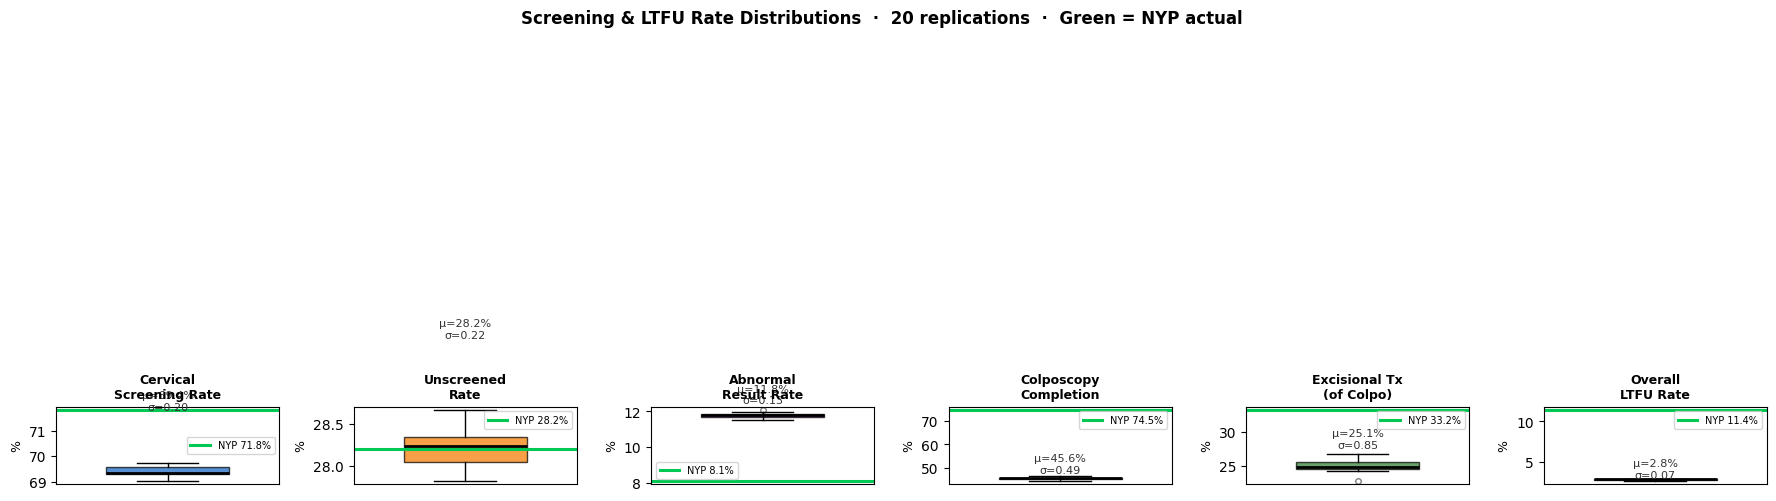


Rate                                    Sim Mean  Sim Std  NYP Actual       Gap  Literature Ref
-----------------------------------------------------------------------------------------------
Cervical Screening Rate                    69.41    0.195       71.8%   -2.39pp  ~80% (HEDIS CCS)
Unscreened Rate                            28.20    0.216       28.2%   -0.00pp  TBD — NYP EHR
Abnormal Result Rate                       11.77    0.128        8.1%   +3.67pp  ~7–8% (ASCCP / SEER)
Colposcopy Completion                      45.64    0.485       74.5%  -28.86pp  ~80% (ASCCP guidance)
Excisional Tx (of Colpo)                   25.07    0.854       33.2%   -8.13pp  ~30–40% (CIN2/3 prevalence)
Overall LTFU Rate                           2.78    0.067       11.4%   -8.62pp  TBD — NYP EHR


In [6]:
rate_specs = [
    ('screening_rate_cervical_pct', 'Cervical\nScreening Rate', '#1565C0'),
    ('unscreened_pct',              'Unscreened\nRate',          '#F57C00'),
    ('abnormal_rate_cervical_pct',  'Abnormal\nResult Rate',     '#6A1B9A'),
    ('colposcopy_completion_pct',   'Colposcopy\nCompletion',    '#C62828'),
    ('treatment_completion_pct',    'Excisional Tx\n(of Colpo)', '#2E7D32'),
    ('ltfu_rate_pct',               'Overall\nLTFU Rate',        '#E65100'),
]

per_rep_rates = defaultdict(list)
for m in all_metrics:
    r = compute_rates(m)
    for key, _, _ in rate_specs:
        per_rep_rates[key].append(r[key])

fig, axes = plt.subplots(1, len(rate_specs), figsize=(18, 5))
for ax, (key, lbl, col) in zip(axes, rate_specs):
    data = per_rep_rates[key]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))
    bp['boxes'][0].set_facecolor(col)
    bp['boxes'][0].set_alpha(0.72)
    ax.set_ylabel('%', fontsize=9)
    ax.set_title(lbl, fontweight='bold', fontsize=9)
    ax.set_xticks([])
    ymax = max(data)
    ax.text(1, ymax * 1.03,
            f'μ={np.mean(data):.1f}%\nσ={np.std(data):.2f}',
            ha='center', fontsize=8, color='#333')
    # NYP actual reference line (green)
    nyp_val = NYP_REFERENCE['rates'].get(key)
    if nyp_val is not None:
        ax.axhline(nyp_val, color='#00C853', linewidth=2.2, linestyle='-',
                   label=f'NYP {nyp_val:.1f}%')
        ax.legend(fontsize=7)

plt.suptitle(
    f'Screening & LTFU Rate Distributions  ·  {N_REPS} replications  ·  Green = NYP actual',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"\n{'Rate':<38} {'Sim Mean':>9} {'Sim Std':>8} {'NYP Actual':>11}  {'Gap':>8}  {'Literature Ref'}")
print("-" * 95)
lit_refs = {
    'screening_rate_cervical_pct': '~80% (HEDIS CCS)',
    'unscreened_pct':              'TBD — NYP EHR',
    'abnormal_rate_cervical_pct':  '~7–8% (ASCCP / SEER)',
    'colposcopy_completion_pct':   '~80% (ASCCP guidance)',
    'treatment_completion_pct':    '~30–40% (CIN2/3 prevalence)',
    'ltfu_rate_pct':               'TBD — NYP EHR',
}
for key, lbl, _ in rate_specs:
    d   = per_rep_rates[key]
    nyp = NYP_REFERENCE['rates'].get(key)
    clean_lbl = lbl.replace('\n', ' ')
    nyp_str = f"{nyp:.1f}%" if nyp is not None else "TBD"
    gap_str = f"{np.mean(d) - nyp:+.2f}pp" if nyp is not None else "—"
    print(f"{clean_lbl:<38} {np.mean(d):>9.2f} {np.std(d):>8.3f} {nyp_str:>11}  {gap_str:>8}  {lit_refs.get(key, '')}")

---

## Cervical Result Distribution — Observed vs. Expected

Bars show the **mean observed rate** across all replications; error bars show ±1 standard deviation. Light bars show the expected probability from `config.py`. Close agreement confirms the stochastic sampling is unbiased relative to the input tables. Divergence points to a bug or a misspecified parameter.

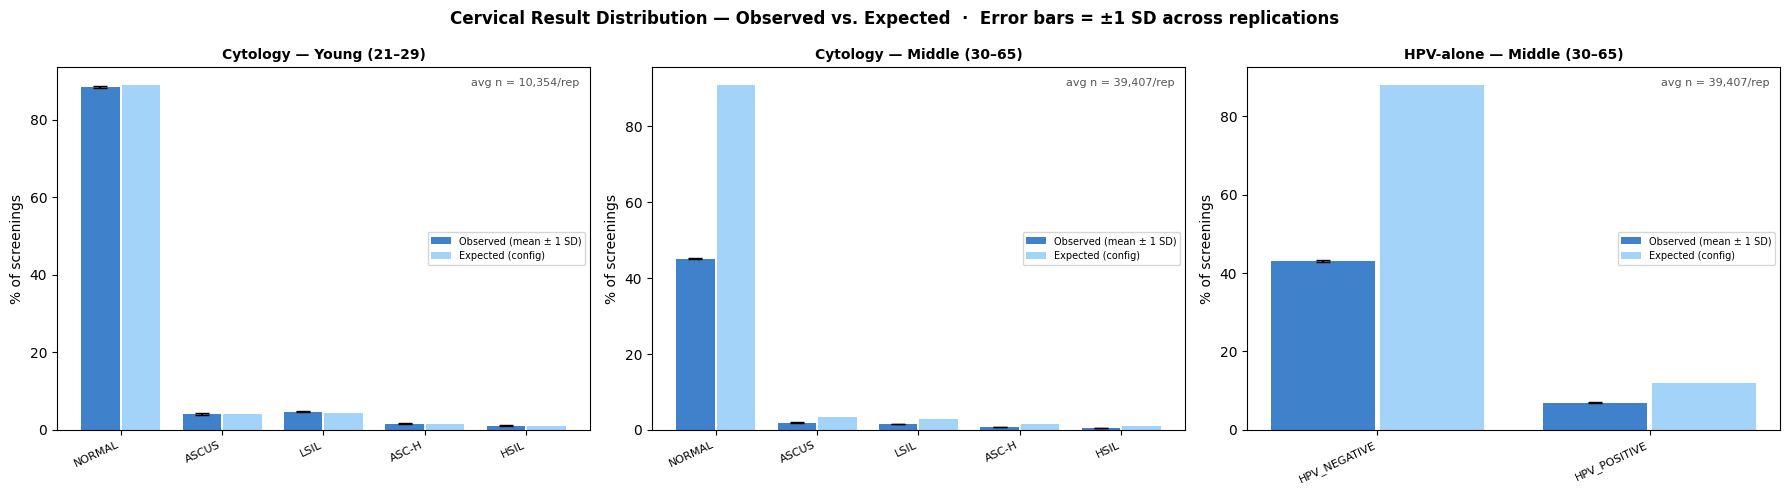

In [7]:
cyto_cats = ['NORMAL', 'ASCUS', 'LSIL', 'ASC-H', 'HSIL']
hpv_cats  = ['HPV_NEGATIVE', 'HPV_POSITIVE']

strata_def = [
    ('young',  'Cytology — Young (21–29)',   'young',           cyto_cats),
    ('middle', 'Cytology — Middle (30–65)',  'middle_cytology', cyto_cats),
    ('middle', 'HPV-alone — Middle (30–65)', 'middle_hpv',      hpv_cats),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (stratum_key, title, cfg_key, cats) in zip(axes, strata_def):
    # Per-replication observed rates
    obs_rates = defaultdict(list)
    for m in all_metrics:
        sub   = m['cervical_by_age_stratum'].get(stratum_key, {})
        total = max(sum(sub.values()), 1)
        for cat in cats:
            obs_rates[cat].append(sub.get(cat, 0) / total * 100)

    means = [np.mean(obs_rates[c]) for c in cats]
    stds  = [np.std(obs_rates[c])  for c in cats]
    exps  = [cfg.CERVICAL_RESULT_PROBS.get(cfg_key, {}).get(c, 0) * 100 for c in cats]

    x = np.arange(len(cats))
    ax.bar(x - 0.2, means, 0.38, yerr=stds, capsize=5,
           color='#1565C0', alpha=0.82, label='Observed (mean ± 1 SD)')
    ax.bar(x + 0.2, exps,  0.38,
           color='#90CAF9', alpha=0.82, label='Expected (config)')
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('% of screenings')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    n_avg = int(np.mean([
        sum(m['cervical_by_age_stratum'].get(stratum_key, {}).values())
        for m in all_metrics
    ]))
    ax.text(0.98, 0.97, f'avg n = {n_avg:,}/rep', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='#555')

plt.suptitle(
    'Cervical Result Distribution — Observed vs. Expected  ·  Error bars = ±1 SD across replications',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

---

## Lung-RADS Distribution — Observed vs. Expected

RADS category mix from all completed LDCTs, pooled across replications, compared to the input probability table in `config.py`. The right panel focuses on the **RADS 4 rate** (the biopsy-trigger rate) — the most clinically consequential metric, and the one most directly comparable to ACR national benchmarks.

> Replace `cfg.LUNG_RADS_PROBS` with NYP LDCT program data once available. ACR national data: RADS 1–2 ≈ 70–80% of screens; RADS 4A/4X ≈ 5–10%.

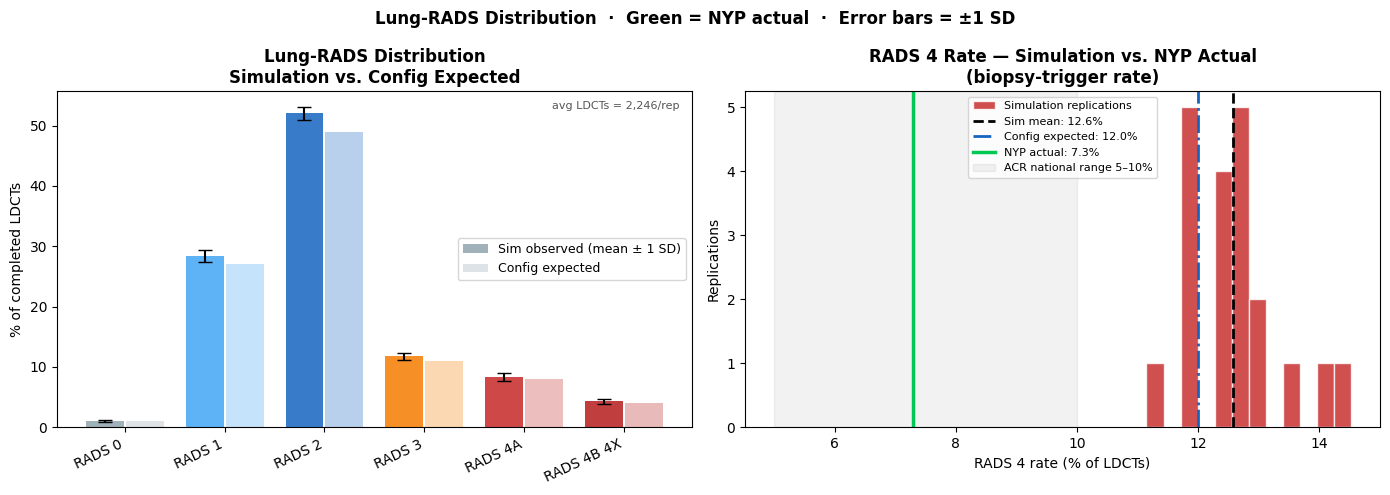


RADS Category   Sim Mean %   Sim SD  Config Exp %   Δ (sim−exp)
---------------------------------------------------------------
RADS_0                 1.0     0.17           1.0         +0.01
RADS_1                28.4     1.04          27.0         +1.38
RADS_2                52.0     1.04          49.0         +3.02
RADS_3                11.7     0.63          11.0         +0.75
RADS_4A                8.3     0.68           8.0         +0.29
RADS_4B_4X             4.3     0.35           4.0         +0.29

RADS 4  |  Sim mean: 12.6%  Sim std: 0.78%  |  NYP actual: 7.3%  |  Gap: +5.28pp


In [8]:
rads_cats   = ['RADS_0', 'RADS_1', 'RADS_2', 'RADS_3', 'RADS_4A', 'RADS_4B_4X']
rads_colors = ['#90A4AE', '#42A5F5', '#1565C0', '#F57C00', '#C62828', '#B71C1C']

obs_rads = defaultdict(list)
for m in all_metrics:
    total_ldct = max(m['lung_ldct_completed'], 1)
    for cat in rads_cats:
        obs_rads[cat].append(m['lung_rads_distribution'].get(cat, 0) / total_ldct * 100)

obs_means = [np.mean(obs_rads[c]) for c in rads_cats]
obs_stds  = [np.std(obs_rads[c])  for c in rads_cats]
exp_vals  = [cfg.LUNG_RADS_PROBS.get(c, 0) * 100 for c in rads_cats]

rads4_rates = [obs_rads['RADS_4A'][i] + obs_rads['RADS_4B_4X'][i] for i in range(N_REPS)]
exp_rads4   = (cfg.LUNG_RADS_PROBS['RADS_4A'] + cfg.LUNG_RADS_PROBS['RADS_4B_4X']) * 100
nyp_rads4   = NYP_REFERENCE['rads4_rate_pct']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Observed vs expected by RADS category ───────────────────────────
ax = axes[0]
x = np.arange(len(rads_cats))
ax.bar(x - 0.2, obs_means, 0.38, yerr=obs_stds, capsize=5,
       color=rads_colors, alpha=0.85, label='Sim observed (mean ± 1 SD)')
ax.bar(x + 0.2, exp_vals,  0.38,
       color=[(*[c/255 for c in rgb], 0.30)
              for rgb in [(144,164,174),(66,165,245),(21,101,192),(245,124,0),(198,40,40),(183,28,28)]],
       label='Config expected')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', ' ') for c in rads_cats], rotation=25, ha='right')
ax.set_ylabel('% of completed LDCTs')
ax.set_title('Lung-RADS Distribution\nSimulation vs. Config Expected', fontweight='bold')
ax.legend(fontsize=9)
n_avg_ldct = int(np.mean([m['lung_ldct_completed'] for m in all_metrics]))
ax.text(0.98, 0.97, f'avg LDCTs = {n_avg_ldct:,}/rep', transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color='#555')

# ── Panel 2: RADS 4 rate distribution vs NYP actual ─────────────────────────
ax2 = axes[1]
ax2.hist(rads4_rates, bins=12, color='#C62828', alpha=0.82, edgecolor='white',
         label='Simulation replications')
ax2.axvline(np.mean(rads4_rates), color='black', linewidth=2.0, linestyle='--',
            label=f'Sim mean: {np.mean(rads4_rates):.1f}%')
ax2.axvline(exp_rads4, color='#1565C0', linewidth=2.0, linestyle='-.',
            label=f'Config expected: {exp_rads4:.1f}%')
ax2.axvline(nyp_rads4, color='#00C853', linewidth=2.5, linestyle='-',
            label=f'NYP actual: {nyp_rads4:.1f}%')
ax2.axvspan(5, 10, alpha=0.10, color='gray', label='ACR national range 5–10%')
ax2.set_xlabel('RADS 4 rate (% of LDCTs)')
ax2.set_ylabel('Replications')
ax2.set_title('RADS 4 Rate — Simulation vs. NYP Actual\n(biopsy-trigger rate)',
              fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle('Lung-RADS Distribution  ·  Green = NYP actual  ·  Error bars = ±1 SD',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n{'RADS Category':<14} {'Sim Mean %':>11} {'Sim SD':>8} {'Config Exp %':>13}  {'Δ (sim−exp)':>12}")
print("-" * 63)
for cat, omean, ostd, exp in zip(rads_cats, obs_means, obs_stds, exp_vals):
    print(f"{cat:<14} {omean:>11.1f} {ostd:>8.2f} {exp:>13.1f}  {omean - exp:>+12.2f}")
print(f"\nRADS 4  |  Sim mean: {np.mean(rads4_rates):.1f}%  "
      f"Sim std: {np.std(rads4_rates):.2f}%  |  "
      f"NYP actual: {nyp_rads4:.1f}%  |  Gap: {np.mean(rads4_rates)-nyp_rads4:+.2f}pp")

---

## Summary Validation Table

All key metrics in one place — simulation mean ± standard deviation alongside the NYP / literature benchmark. Fill in the **NYP Reference** column once EHR and Finance data are extracted. Values that diverge from the literature by more than ~10 percentage points should be re-examined in `config.py`.

In [9]:
def _rep_vals(key):
    return [m[key] for m in all_metrics]

def _fn_vals(fn):
    return [fn(m) for m in all_metrics]

def _rate_vals(key):
    return [compute_rates(m)[key] for m in all_metrics]

NYP = NYP_REFERENCE   # shorthand

rows = [
    # (section, metric, sim_vals, nyp_val, unit)
    ("Volume",
     "Patients simulated / year",
     _rep_vals('n_patients'),
     NYP['n_patients_annual'], "count"),

    ("Volume",
     "Eligible for cervical screening",
     _fn_vals(lambda m: m['n_eligible'].get('cervical', 0)),
     NYP['n_eligible_cervical_annual'], "count"),

    ("Volume",
     "Eligible for lung LDCT",
     _rep_vals('lung_eligible'),
     NYP['n_eligible_lung_annual'], "count"),

    ("Cervical Screening",
     "Screening rate",
     _rate_vals('screening_rate_cervical_pct'),
     NYP['rates']['screening_rate_cervical_pct'], "%"),

    ("Cervical Screening",
     "Abnormal result rate",
     _rate_vals('abnormal_rate_cervical_pct'),
     NYP['rates']['abnormal_rate_cervical_pct'], "%"),

    ("Cervical Screening",
     "Colposcopy completion (of abnormals)",
     _rate_vals('colposcopy_completion_pct'),
     NYP['rates']['colposcopy_completion_pct'], "%"),

    ("Cervical Screening",
     "Excisional tx rate (of colposcopies)",
     _rate_vals('treatment_completion_pct'),
     NYP['rates']['treatment_completion_pct'], "%"),

    ("LTFU",
     "Overall LTFU rate",
     _rate_vals('ltfu_rate_pct'),
     NYP['rates']['ltfu_rate_pct'], "%"),

    ("LTFU",
     "Post-abnormal LTFU (count/yr)",
     _rep_vals('ltfu_post_abnormal'),
     None, "count"),

    ("LTFU",
     "Post-colposcopy LTFU (count/yr)",
     _rep_vals('ltfu_post_colposcopy'),
     None, "count"),

    ("Lung LDCT",
     "LDCTs completed / year",
     _rep_vals('lung_ldct_completed'),
     NYP['n_ldct_completed_annual'], "count"),

    ("Lung LDCT",
     "RADS 4 rate (biopsy trigger)",
     rads4_rates,
     NYP['rads4_rate_pct'], "%"),

    ("Lung LDCT",
     "Malignancy confirmed / year",
     _rep_vals('lung_malignancy_confirmed'),
     NYP['n_malignancy_confirmed'], "count"),

    ("Revenue (placeholder CPT rates)",
     "Realized revenue / year ($)",
     realized_totals,
     NYP['realized_total_annual'], "$"),

    ("Revenue (placeholder CPT rates)",
     "Foregone revenue / year ($)",
     foregone_totals,
     NYP['foregone_total_annual'], "$"),

    ("Revenue (placeholder CPT rates)",
     "Revenue capture rate",
     capture_rates,
     NYP['capture_rate_pct'], "%"),
]

# ── Print table ────────────────────────────────────────────────────────────────
def _fmt(v, unit):
    if unit == "$":     return f"${v:,.0f}"
    elif unit == "%":   return f"{v:.1f}%"
    else:               return f"{v:,.0f}"

print(f"{'Section':<32} {'Metric':<42} {'Sim Mean':>12} {'±SD':>9} {'NYP Actual':>12}  {'Gap (sim−nyp)':>14}")
print("=" * 127)

last_sec = None
for section, metric, vals, nyp_val, unit in rows:
    if section != last_sec:
        print(f"\n  [{section}]")
        last_sec = section
    mu = np.mean(vals); sd = np.std(vals)
    nyp_str = _fmt(nyp_val, unit) if nyp_val is not None else "TBD"
    gap_str = _fmt(mu - nyp_val, unit) if nyp_val is not None else "—"
    # prepend + sign for positive gaps
    if nyp_val is not None and mu - nyp_val > 0 and not gap_str.startswith('-'):
        gap_str = '+' + gap_str
    print(f"    {metric:<42} {_fmt(mu, unit):>12} {('±'+_fmt(sd,unit).lstrip('$')):>9} "
          f"{nyp_str:>12}  {gap_str:>14}")

print("\n" + "=" * 127)
print(f"Replications: {N_REPS}   Horizon: {N_DAYS} days   *** NYP values are PLACEHOLDER — replace with real data ***")
print("Revenue uses PLACEHOLDER CPT rates — replace cfg.PROCEDURE_REVENUE with NYP contract rates.")

Section                          Metric                                         Sim Mean       ±SD   NYP Actual   Gap (sim−nyp)

  [Volume]
    Patients simulated / year                        71,692       ±62       68,400          +3,292
    Eligible for cervical screening                  49,762      ±133       31,200         +18,562
    Eligible for lung LDCT                            3,890       ±78        1,850          +2,040

  [Cervical Screening]
    Screening rate                                    69.4%     ±0.2%        71.8%           -2.4%
    Abnormal result rate                              11.8%     ±0.1%         8.1%           +3.7%
    Colposcopy completion (of abnormals)              45.6%     ±0.5%        74.5%          -28.9%
    Excisional tx rate (of colposcopies)              25.1%     ±0.9%        33.2%           -8.1%

  [LTFU]
    Overall LTFU rate                                  2.8%     ±0.1%        11.4%           -8.6%
    Post-abnormal LTFU (count/yr) 